In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("tested.csv") 

In [3]:
# Missing Value Percentage  
(data.isnull().sum()/len(data))*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            20.574163
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.239234
Cabin          78.229665
Embarked        0.000000
dtype: float64

In [4]:
# Age
data['Age'] = data['Age'].fillna(data["Age"].median())
data['Age']

0      34.5
1      47.0
2      62.0
3      27.0
4      22.0
       ... 
413    27.0
414    39.0
415    38.5
416    27.0
417    27.0
Name: Age, Length: 418, dtype: float64

In [5]:
# Embarked
data['Embarked']=data['Embarked'].fillna(data['Embarked'].mode()[0])
data["Embarked"]

0      Q
1      S
2      Q
3      S
4      S
      ..
413    S
414    C
415    S
416    S
417    C
Name: Embarked, Length: 418, dtype: str

In [6]:
# Cabin
data.drop("Cabin", axis=1, inplace=True)

In [ ]:
# Duplicate Values:-

data.duplicated().sum()

np.int64(0)

In [8]:
# Remove duplicates
data.drop_duplicates(inplace=True)
data.duplicated().sum()

np.int64(0)

Calculate Quartile :-

In [9]:
Q1 = data["Age"].quantile(0.25)
Q3 = data["Age"].quantile(0.75)
print("Q1 =", Q1)
print("Q3 =", Q3)

Q1 = 23.0
Q3 = 35.75


In [10]:
# Calculate IQR
IQR = Q3 - Q1
IQR

np.float64(12.75)

In [11]:
# Calculate Lower and Upper Limits
lower_limit = Q1 - 1.5 * IQR
# Calculation:
24 - (1.5 * 7)

13.5

In [12]:
upper_limit = Q3 + 1.5 * IQR
# Calculation:
31 + (1.5 * 7)

41.5

In [13]:
# Detect Outliers

age_outliers = data[
    (data["Age"] < lower_limit) |
    (data["Age"] > upper_limit)
]
print(age_outliers)

     PassengerId  Survived  Pclass  \
2            894         0       2   
13           905         0       2   
20           912         0       1   
48           940         1       1   
69           961         1       1   
77           969         1       1   
81           973         0       1   
89           981         0       2   
96           988         1       1   
114         1006         1       1   
117         1009         1       3   
142         1034         0       1   
152         1044         0       3   
179         1071         1       1   
193         1085         0       2   
201         1093         0       3   
213         1105         1       2   
217         1109         0       1   
236         1128         0       1   
240         1132         1       1   
250         1142         1       2   
263         1155         1       3   
281         1173         0       3   
284         1176         1       3   
296         1188         1       2   
305         

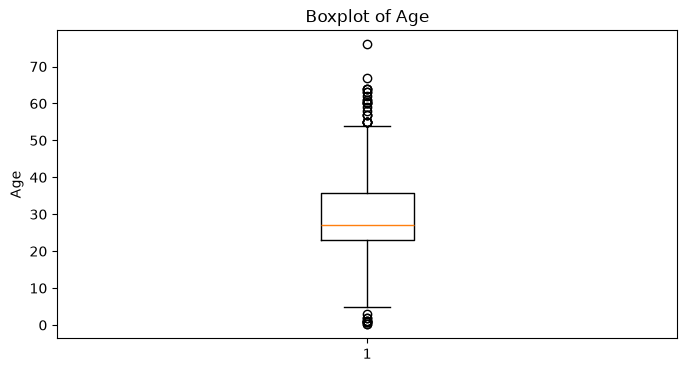

In [15]:
# for data visualisation

plt.figure(figsize=(8,4))
plt.boxplot(data['Age'])
plt.title("Boxplot of Age")
plt.ylabel("Age")
plt.show()

In [16]:
data['Ticket']

0                  330911
1                  363272
2                  240276
3                  315154
4                 3101298
              ...        
413             A.5. 3236
414              PC 17758
415    SOTON/O.Q. 3101262
416                359309
417                  2668
Name: Ticket, Length: 418, dtype: str

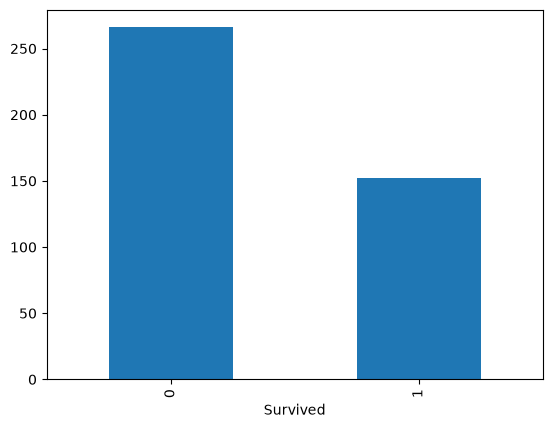

In [17]:
data["Survived"].value_counts().plot(kind="bar")
plt.show()

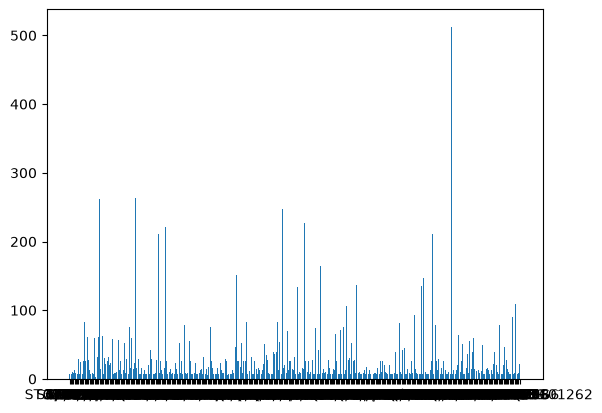

In [18]:
data1=data["Ticket"]
data2=data["Fare"]
plt.bar(data1,data2)
plt.show()

In [19]:
# Survial vs Passenger Class

pd.crosstab(data['Pclass'], data['Survived'])

Survived,0,1
Pclass,,
1,57,50
2,63,30
3,146,72


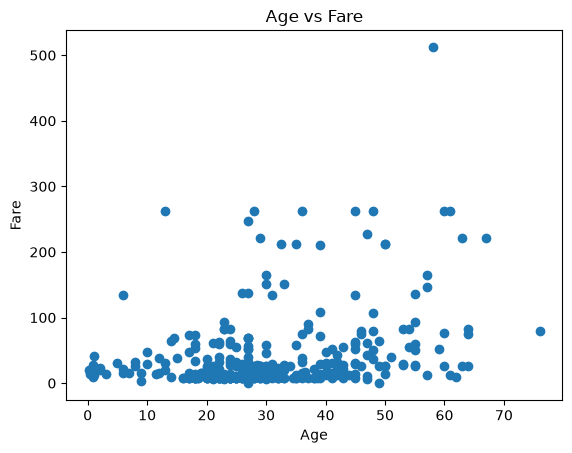

In [20]:
plt.scatter(data['Age'], data['Fare'])
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Age vs Fare")
plt.show()